<a href="https://colab.research.google.com/github/IsabelleBic20/Estrutura-de-Dados-e-Algoritmos-Anota-es/blob/main/Modelo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from torch.utils.data import Dataset
import torch
import os
from PIL import Image
import torch
import numpy as np

class SegmentationDataset(Dataset):
    def __init__(self, path_rgb, path_labels, transforms=None):
        self.path_rgb = path_rgb
        self.path_labels = path_labels
        self.transforms = transforms

        rgb_files = [f for f in os.listdir(self.path_rgb) if f.endswith(('.png', '.jpg'))]
        label_files = [f for f in os.listdir(self.path_labels) if f.endswith('.png')]

        self.filenames = []
        self.labels_map = {}
        for rgb in rgb_files:
            prefix = "_".join(rgb.split("_")[:4])
            matched_label = [l for l in label_files if l.startswith(prefix)]
            if matched_label:
                self.filenames.append(rgb)
                self.labels_map[rgb] = matched_label[0]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        rgb_name = self.filenames[idx]
        label_name = self.labels_map[rgb_name]

        image = Image.open(os.path.join(self.path_rgb, rgb_name)).convert("RGB")
        mask = Image.open(os.path.join(self.path_labels, label_name))

        if self.transforms:
            image, mask = self.transforms(image, mask)

        mask = torch.tensor(np.array(mask), dtype=torch.long)
        mask = torch.clamp(mask, 0, 1) # Clamp mask values to be 0 or 1
        return image, mask

In [ ]:
import os

base_path = "/content/drive/MyDrive/imagens tcc/train_all"
train_rgb = f"{base_path}/treino/rgb"
train_labels = f"{base_path}/treino/labels"


In [ ]:
import torchvision.transforms.v2 as transforms

# augmentations e normalização
data_transforms_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.PILToTensor(),
    ])

data_transforms_val = transforms.Compose([
        transforms.PILToTensor(),
    ])


In [ ]:
base_path = "/content/drive/MyDrive/imagens tcc/train_all"

train_rgb = f"{base_path}/treino/rgb"
train_labels = f"{base_path}/treino/labels"

val_rgb = f"{base_path}/validacao/rgb"
val_labels = f"{base_path}/validacao/labels"

In [ ]:
# datasets
image_dataset_train = SegmentationDataset(train_rgb, train_labels, transforms=data_transforms_train)
image_dataset_val = SegmentationDataset(val_rgb, val_labels, transforms=data_transforms_val)

# dataloaders
from torch.utils.data import DataLoader

dataloader_train = DataLoader(image_dataset_train, batch_size=4, shuffle=True, num_workers=2)
dataloader_val = DataLoader(image_dataset_val, batch_size=4, shuffle=False, num_workers=2)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/imagens tcc/train_all/treino/rgb'

Visualizando algumas imagens de treinamento


torch.Size([4, 3, 256, 256])
torch.Size([4, 1, 256, 256])


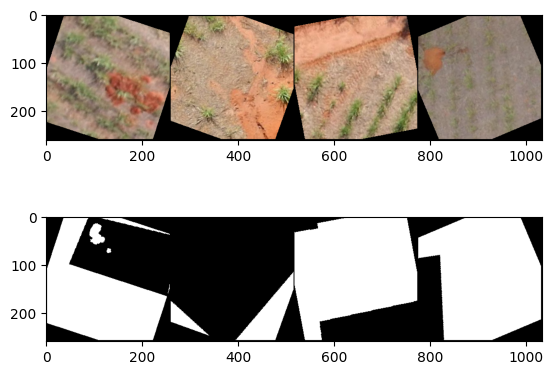

In [ ]:
import matplotlib.pyplot as plt
import torchvision

def imshow(inp1, inp2):
  figure, axis = plt.subplots(2, 1)
  inp1 = inp1.numpy().transpose((1, 2, 0))
  inp2 = inp2.numpy().transpose((1, 2, 0))
  axis[0].imshow(inp1)
  axis[1].imshow(inp2*255)
  plt.pause(0.001)  # pausar um pouco

# Obtendo um batch do conjunto de treino
inputs, masks = next(iter(dataloader_train))

print(inputs.shape)
print(masks.shape)

out1 = torchvision.utils.make_grid(inputs)
out2 = torchvision.utils.make_grid(masks)

imshow(out1, out2)

# Criando o modelo

In [ ]:
class UNet_down_block(torch.nn.Module):
    def __init__(self, input_channel, output_channel, down_size):
        super(UNet_down_block, self).__init__()
        self.conv1 = torch.nn.Conv2d(input_channel, output_channel, 3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(output_channel)
        self.conv2 = torch.nn.Conv2d(output_channel, output_channel, 3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(output_channel)
        self.max_pool = torch.nn.MaxPool2d(2, 2)
        self.relu = torch.nn.ReLU()
        self.down_size = down_size

    def forward(self, x):
        if self.down_size:
            x = self.max_pool(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

In [ ]:
class UNet_up_block(torch.nn.Module):
    def __init__(self, prev_channel, input_channel, output_channel):
        super(UNet_up_block, self).__init__()
        self.up_sampling = torch.nn.Upsample(scale_factor=2, mode='bilinear')
        self.conv1 = torch.nn.Conv2d(prev_channel + input_channel, output_channel, 3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(output_channel)
        self.conv2 = torch.nn.Conv2d(output_channel, output_channel, 3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(output_channel)
        self.relu = torch.nn.ReLU()

    def forward(self, prev_feature_map, x):
        x = self.up_sampling(x)
        x = torch.cat((x, prev_feature_map), dim=1)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

In [ ]:
class UNet(torch.nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        self.down_block1 = UNet_down_block(3, 64, False)
        self.down_block2 = UNet_down_block(64, 128, True)
        self.down_block3 = UNet_down_block(128, 256, True)
        self.down_block4 = UNet_down_block(256, 512, True)
        self.down_block5 = UNet_down_block(512, 1024, True)

        self.up_block1 = UNet_up_block(512, 1024, 512)
        self.up_block2 = UNet_up_block(256, 512, 256)
        self.up_block3 = UNet_up_block(128, 256, 128)
        self.up_block4 = UNet_up_block(64, 128, 64)

        self.last_conv = torch.nn.Conv2d(64, 2, 1, padding=0)

    def forward(self, x):
        self.x1 = self.down_block1(x)
        self.x2 = self.down_block2(self.x1)
        self.x3 = self.down_block3(self.x2)
        self.x4 = self.down_block4(self.x3)
        self.x5 = self.down_block5(self.x4)
        x = self.up_block1(self.x4, self.x5)
        x = self.up_block2(self.x3, x)
        x = self.up_block3(self.x2, x)
        x = self.up_block4(self.x1, x)
        x = self.last_conv(x)
        return x

## Treinando o modelo

Agora, vamos escrever uma função geral para treinar um modelo. Aqui, vamos ilustrar:

- Agendamento da taxa de aprendizagem
- Salvando o melhor modelo


In [ ]:
import time
from tempfile import TemporaryDirectory

def train_model(model, criterion, optimizer, num_epochs=25):
    since = time.time()

    # Cria um diretório temporário para salver os checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pth')

        torch.save(model.state_dict(), best_model_params_path)
        best_loss = float('inf')

        for epoch in range(num_epochs):
            print(f'Época {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Para época temos a fase de treino e teste
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                    dataloader = dataloader_train
                    dataset_size = dataset_size_train
                else:
                    model.eval()
                    dataloader = dataloader_val
                    dataset_size = dataset_size_val

                running_loss = 0.0

                # Iteração sobre o dataset
                for inputs, labels in dataloader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    inputs = inputs.float()
                    labels = labels.long()

                    # zerando o gradiente
                    optimizer.zero_grad()

                    # forward
                    # salvando o histórico apenas no treino
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        #_, preds = torch.max(outputs, 1)

                        loss = criterion(outputs, labels.squeeze(dim=1))

                        # backward + optimização apenas na fase de treino
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)

                epoch_loss = running_loss / dataset_size

                print(f'{phase} Loss: {epoch_loss:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_loss < best_loss:
                    best_loss = epoch_loss
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Treinamento completo em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Melhor val Acc: {best_loss:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path))
    return model

### Treinando e avaliando


In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = UNet()
model.to(device)

num_classes = 2
criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)



In [ ]:
dataset_size_train = len(image_dataset_train)
dataset_size_val = len(image_dataset_val)

model = train_model(model, criterion, optimizer, num_epochs=20)

Época 0/19
----------


In [ ]:
model = train_model(model, criterion, optimizer, num_epochs=20)


In [ ]:
import torch

PATH = '/content/drive/MyDrive/imagens tcc/train_all/modelos/u_net.pth'
torch.save(model.state_dict(), PATH)

model = UNet()
model.load_state_dict(torch.load(PATH))
model.to(device)

In [ ]:
def open_img(img_path):
  img = Image.open(img_path)
  img = data_transforms_val(img)
  img = img.unsqueeze(0)
  img = img.to(device)
  return img

In [ ]:
import torch.nn.functional as F

inputs, masks = next(iter(dataloader_test))
inputs = inputs.to(device)
inputs = inputs.float()

outputs = model(inputs)
outputs = F.softmax(outputs, dim=1)

model.eval()
with torch.no_grad():
  pred = model(inputs)
  pred = pred.data.cpu().numpy()

In [ ]:
import numpy as np

idx = 1
prediction = np.argmax(pred[idx], axis=0)
rgb = inputs[idx].data.cpu().numpy()
rgb = np.transpose(rgb, (1, 2, 0)).astype(np.uint8)
print(prediction.shape)